In [298]:
# Всё необходимое для выполнения данной лабораторной работы!
import requests
from time import sleep

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import folium as fl

## Задание 1. Парсинг

В этом задании Вам предстоит работать с API сайта <a target="_blank" href="hh.ru">hh.ru</a>. Документация доступна по <a target="_blank" href="https://github.com/hhru/api/blob/master/docs/vacancies.md#search">ссылке</a>.

**Задача:**
1. выбрать 5 интересующих вас профессий (не смежных, т.е. Аналатик и Data Engineer не считается корректным)
2. затем получить доступные по данным профессиям вакансии в Москве и выделить их физические координаты
3. нанести полученные координаты на карту местоположения компаний

*Пример запроса для профессии:*

In [462]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': "физик ядерщик",
    'area': 1,
    'page': 0,
    'per_page': 10
}

data = requests.get(URL, params).json()

Если Ваш запрос прошел успешно, то вы получите следующие ключи (значения данных ключей вы найдете по ссылке на документацию):

In [300]:
data.keys()

dict_keys(['items', 'found', 'pages', 'page', 'per_page', 'clusters', 'arguments', 'fixes', 'suggests', 'alternate_url'])

Выберите для нас 5 наиболее интересных специальностей и получите по ним имеющиеся вакансии:

In [302]:
vacancies = ['Unity разработчик', 'Аналитик Данных', 'Маркетолог', 'Звукорежиссёр', 'Веб дизайнер']
vacancies_db = {} # сюда положим все ваки по каждой професии

for vacancy in vacancies:
    print(f'currently in vacancies DB:')
    for i in vacancies_db:
        print(i, ': ', len(vacancies_db[i]), sep='')
    
    page = 0
    
    print(f'\nsearching for {vacancy} in hh.ru')
    while True:
        params = {
            'text': vacancy,
            'area': 1,
            'page': page,
            'per_page': 100 
        }
        
        try:
            data = requests.get(URL, params).json()
            print(f'found {len(data["items"])} vacancies "{vacancy}" on page {page}')
            
            if len(data['items']) != 0: # если вакансий меньше 2000, то в момент когда они закончатся, API вернёт пустой список вакансий
                
                if not (vacancy in vacancies_db): # алгоритм для создания/пополнения списка в словаре
                    vacancies_db[vacancy] = data['items']
                    print(f'{vacancy} created in DB')
                else:
                    vacancies_db[vacancy].extend(data['items'])
                    print(f'{vacancy} found in DB. Adding {len(data["items"])} new vacancies. {len(vacancies_db[vacancy])} vacancies total.')
            
            else:
                print(f'End of process. {len(vacancies_db[vacancy])} jobs found. ')
                break
        except KeyError:  # когда API упирается в потолок 2000 вакансий (ограничение hh.ru), выдаёт ошибку KeyError
            print(f'Exception KeyError. End of process. {len(vacancies_db[vacancy])} jobs found. ')
            break
    
        page += 1

    clear_output(wait=True)

currently in vacancies DB:
Unity разработчик: 98
Аналитик Данных: 2000
Маркетолог: 2000
Звукорежиссёр: 26

searching for Веб дизайнер in hh.ru
found 100 vacancies "Веб дизайнер" on page 0
Веб дизайнер created in DB
found 100 vacancies "Веб дизайнер" on page 1
Веб дизайнер found in DB. Adding 100 new vacancies. 200 vacancies total.
found 100 vacancies "Веб дизайнер" on page 2
Веб дизайнер found in DB. Adding 100 new vacancies. 300 vacancies total.
found 100 vacancies "Веб дизайнер" on page 3
Веб дизайнер found in DB. Adding 100 new vacancies. 400 vacancies total.
found 100 vacancies "Веб дизайнер" on page 4
Веб дизайнер found in DB. Adding 100 new vacancies. 500 vacancies total.
found 100 vacancies "Веб дизайнер" on page 5
Веб дизайнер found in DB. Adding 100 new vacancies. 600 vacancies total.
found 100 vacancies "Веб дизайнер" on page 6
Веб дизайнер found in DB. Adding 100 new vacancies. 700 vacancies total.
found 100 vacancies "Веб дизайнер" on page 7
Веб дизайнер found in DB. Adding

Посчитайте сколько всего найдено вакансий:

In [303]:
total = 0

for i in vacancies_db:
    print(f'{i}: {len(vacancies_db[i])}')
    total += len(vacancies_db[i])

print('Total:', total)

Unity разработчик: 98
Аналитик Данных: 2000
Маркетолог: 2000
Звукорежиссёр: 26
Веб дизайнер: 868
Total: 4992


Создайте структуру данных, которая будет хранить в себе имя компании и ее координаты (широта и долгота):

In [304]:
companies = []
vacancy_name = []
lat = []
lng = []

for i in vacancies_db:
  for j in range(len(vacancies_db[i])):
    companies.append(vacancies_db[i][j]['employer']['name'])
      
    try:
      vacancy_name.append(vacancies_db[i][j]['name'])
    except TypeError:
      vacancy_name.append('NaN')
        
    try:
      lat.append(vacancies_db[i][j]['address']['lat'])
    except TypeError:
      lat.append('NaN')

    try:
      lng.append(vacancies_db[i][j]['address']['lng'])
    except TypeError:
      lng.append('NaN')

hh_df = pd.DataFrame()
hh_df['company'] = companies
hh_df['vacancy_name'] = vacancy_name
hh_df['lat'] = lat
hh_df['lng'] = lng

hh_df

,company,vacancy_name,lat,lng
0,Атерикс Технолоджис,QA-тестировщик (Web/Android),NaN,NaN
1,Телетауэр Студиос,Unity Developer (Middle/ Middle+),NaN,NaN
2,Door 407,Тестировщик,55.991893,37.21439
3,Astrum Entertainment,Программист Unity (Мир Домовят),NaN,NaN
4,Azur Games,Middle QA Engineer (hybrid casual),NaN,NaN
...,...,...,...,...
4987,Теремок,Разработчик Flutter (Middle+/Senior),55.738451,37.588011
4988,Теремок,Разработчик Flutter (Middle+/Senior),55.738451,37.588011
4989,Общероссийская общественная организация Россий...,Интернет-маркетолог,55.691552,37.572396
4990,Теремок,Разработчик Flutter (Middle+/Senior),55.738451,37.588011


Создайте экземпляр этой структуры данных для каждой компании, которая выставила вакансию:

In [ ]:
??? не понял(

Найдите количество вакансий, у которых заданы координаты (значения данных может быть пустым):

In [305]:
geo_not_stated = hh_df.shape[0] - hh_df[hh_df['lat'] == 'NaN'].shape[0]
print(f'''Total: {hh_df.shape[0]}
Geo not stated: {hh_df[hh_df["lat"] == "NaN"].shape[0]}
Difference: {geo_not_stated}''')

Total: 4992
Geo not stated: 2071
Difference: 2921


Отберите вакансии, которые расположены в пределах МКАД (можно грубо):

Долгота
37.367872 запад
37.842837 восток

Широта
55.894731 север
55.576395 юг

In [307]:
within_mkad = geo_stated[((geo_stated['lat'] < 55.894731) & (geo_stated['lat'] > 55.576395)) & ((geo_stated['lng'] < 37.842837) & (geo_stated['lng'] > 37.367872))]
within_mkad.shape[0]

2534

Постройте график в координатах "широта-долгота" для отображения вакансий внутри МКАД (не забывайте прописать прозрачность, чтобы увидеть скопления):

<Axes: xlabel='lat', ylabel='lng'>

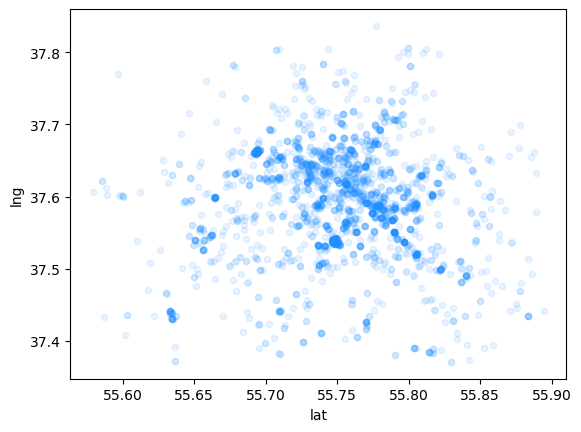

In [464]:
within_mkad.plot(kind='scatter', x='lat', y='lng', c='dodgerblue', alpha=0.1)

In [309]:
# Я не мог не попробовать

map_object = fl.Map(location=[55.594731, 37.642837], zoom_start=12)
for i in range(hh_df.shape[0]):
    try:
        fl.Marker([within_mkad.iloc[i]['lat'], within_mkad.iloc[i]['lng']]).add_to(map_object)
    except IndexError:
        break

In [310]:
# БОЖЕ ПРОСТИ МЕНЯ ЗА ВСЕ МОИ ГРЕХИ

map_object

**Сделайте выводы о проделанной работе:**

*******************************************************************************************************************************************
Спарсили 4992 вакансий с hh.ru
Создали датасет с названиями вакансий, названиями компаний, широтой и долготой места.
2921 вакансий с указанными координатами и 2534 в пределах МКАДа
Отметили вакансии на точечной диаграмме и карте.
Видны скопления вдоль трасс, где в основном расположены бизнес-центры. Причём, скопление имеет форму Х. Есть небольшое смещение в правую сторону Москвы. Также есть скопление в Москве-сити
*******************************************************************************************************************************************

Вам предстоит проанализировать датасет, содержащий информацию об бриллианта, их стоимости и остальных характеристиках.



Поясним значения хранящиеся в колонках:
*   `cut` - огранка бриллианта (относится к одной из примерно 10 наиболее распространенных)
*   `color` - цвет бриллианта, прозрачные бриллианты имеют градацию `D-Z`, "более высокие" буквы - более желтоватые, но часто имеют лучшие значения, поскольку цвет трудно определить один раз в кольце
*   `clarity` - чистота бриллианта, наличие включений (внутренних дефектов), чем меньше и мельче, тем лучше
*   `carat_weight` - масса бриллианта (слабо связана с размером бриллианта, т.к. огранка и качество огранки, как правило, играют большую роль)
*   `cut_quality` - качество ограники по системе оценки GIA Cut
*   `lab` - лаборатория оценивания
*   `meas_length` - длина бриллианта
*   `meas_width` - ширина бриллианта
*   `meas_depth` - глубина бриллианта
*   `total_sales_price` - цена бриллианта в долларах.
*    **и прочие колонки**

Скачаем данные:

In [ ]:
!gdown 10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
# если работайте в jupyter то скачайте датасет с https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8

Создадим DataFrame:

In [311]:
import pandas as pd

diamonds = pd.read_csv("diamonds.csv")

Выведете первые 5 строк датасета:

In [312]:
diamonds.head(5)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


Найдите количество бриллиантов всего в данном датасете:

In [313]:
diamonds.shape[0]

219703

Выведите максимальную и минимальную цену бриллианта в формате `номер - цена`:

In [315]:
print(f'''Maximum price
{diamonds['total_sales_price'].idxmax()} - {diamonds['total_sales_price'].max()}
Minimum price
{diamonds['total_sales_price'].idxmin()} - {diamonds['total_sales_price'].min()}
''')

Maximum price
219702 - 1449881
Minimum price
0 - 200



Посчитайте количество пропусков (пропуском считается значение `unknown` или `None`):

In [316]:
# Сначала приведу всё к единому NaN
diamonds.replace('unknown', np.nan, inplace=True)
diamonds.replace('None', np.nan, inplace=True)

In [317]:
diamonds.isna().sum()

Unnamed: 0                          0
cut                                 0
color                            9162
clarity                             0
carat_weight                        0
cut_quality                     60607
lab                                 0
symmetry                            0
polish                              0
eye_clean                      156916
culet_size                      85740
culet_condition                204384
depth_percent                       0
table_percent                       0
meas_length                         0
meas_width                          0
meas_depth                          0
girdle_min                      83432
girdle_max                      84295
fluor_color                    203977
fluor_intensity                143619
fancy_color_dominant_color     210539
fancy_color_secondary_color    218641
fancy_color_overtone           219315
fancy_color_intensity          210541
total_sales_price                   0
dtype: int64

Найдите в каких столбцах присутствуют пропуски:

In [318]:
nan_columns = []
for i in diamonds.isna().sum().keys():
    if diamonds.isna().sum()[i] != 0:
        nan_columns.append(i)
print(f'Пропуски присутствуют в столбцах: {", ".join(nan_columns)}')

Пропуски присутствуют в столбцах: color, cut_quality, eye_clean, culet_size, culet_condition, girdle_min, girdle_max, fluor_color, fluor_intensity, fancy_color_dominant_color, fancy_color_secondary_color, fancy_color_overtone, fancy_color_intensity


В нашем датасете присутствуют колонки, которые начинаются с `fancy_color_` или `fluor_`. Большинство значений в этих колонках - `unknown` или `None`, поэтому мы считаем их малоинформативными.

Ваша задача:

найти количество таких колонок, которые начинаются с `fancy_color_` или `fluor_`:

In [319]:
fancy_fluor_columns = []

print('Ищем колонки, начинающиеся с "fancy_color_" или "fluor_"...')
for i in diamonds.isna().sum().keys():
    if i.startswith('fancy_color_') or i.startswith('fluor_'):
        print(f'Найдена колонка {i}')
        fancy_fluor_columns.append(i)
print('Конец поиска.')
print(f'''\nКолонки, которые начинаются с fancy_color_ или fluor_: {', '.join(fancy_fluor_columns)}\nВсего таких колонок: {len(fancy_fluor_columns)}''')

Ищем колонки, начинающиеся с "fancy_color_" или "fluor_"...
Найдена колонка fluor_color
Найдена колонка fluor_intensity
Найдена колонка fancy_color_dominant_color
Найдена колонка fancy_color_secondary_color
Найдена колонка fancy_color_overtone
Найдена колонка fancy_color_intensity
Конец поиска.

Колонки, которые начинаются с fancy_color_ или fluor_: fluor_color, fluor_intensity, fancy_color_dominant_color, fancy_color_secondary_color, fancy_color_overtone, fancy_color_intensity
Всего таких колонок: 6


найти количество информативных (не `None` или `unknown`) значений в этих колонках:

In [320]:
diamonds[fancy_fluor_columns].notna().sum()

fluor_color                    15726
fluor_intensity                76084
fancy_color_dominant_color      9164
fancy_color_secondary_color     1062
fancy_color_overtone             388
fancy_color_intensity           9162
dtype: int64

удалить данные колонки из датасета, сохранив изменения (в дальнейшем работаем измененным датасетом):

In [321]:
diamonds.drop(fancy_fluor_columns, axis=1, inplace=True)

Проделайте тоже самое для колонок, начинающихся с `culet_`:

In [322]:
culet_columns = []

print('Ищем колонки, начинающиеся с "culet_"...')
for i in diamonds.isna().sum().keys():
    if i.startswith('culet_'):
        print(f'Найдена колонка {i}')
        culet_columns.append(i)
print('Конец поиска')
print(f'''\nКолонки, которые начинаются с culet_: {', '.join(culet_columns)}\nВсего таких колонок: {len(culet_columns)}''')

Ищем колонки, начинающиеся с "culet_"...
Найдена колонка culet_size
Найдена колонка culet_condition
Конец поиска

Колонки, которые начинаются с culet_: culet_size, culet_condition
Всего таких колонок: 2


In [323]:
diamonds.drop(culet_columns, axis=1, inplace=True)

Посчитайте сколько бы стоил (в тысячах долларов) сейф, в котором хранились бы все бриллианты из датасета:

In [324]:
diamonds['total_sales_price'].sum()

1517721991

Немного необоснованных манипуляций.

Выберите из датасета строки с четными индексами и выведете значения (не меняя нумерацию индексов):

In [325]:
diamonds[diamonds.index % 2 == 0].head(10)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,NaN,62.7,59.0,2.85,2.87,1.79,M,M,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,NaN,61.1,59.0,2.88,2.90,1.77,TN,M,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,NaN,64.9,58.5,2.79,2.83,1.82,STK,STK,200
6,6,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,64.0,57.0,2.85,2.88,1.84,STK,STK,200
8,8,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,63.5,59.5,2.89,2.92,1.85,STK,TK,200
10,10,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,62.2,58.5,2.82,2.85,1.77,STK,TK,200
12,12,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,61.8,58.5,2.85,2.89,1.77,STK,TK,200
14,14,Round,E,VVS2,0.09,Very Good,IGI,Excellent,Very Good,NaN,63.6,58.0,2.81,2.84,1.79,STK,STK,200
16,16,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,62.3,55.5,2.88,2.91,1.80,STK,STK,200
18,18,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,NaN,61.0,60.0,2.91,2.92,1.78,M,M,200


А теперь с индексами, кратными 6:

In [326]:
diamonds[diamonds.index % 6 == 0].head(10)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,NaN,62.7,59.0,2.85,2.87,1.79,M,M,200
6,6,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,64.0,57.0,2.85,2.88,1.84,STK,STK,200
12,12,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,NaN,61.8,58.5,2.85,2.89,1.77,STK,TK,200
18,18,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,NaN,61.0,60.0,2.91,2.92,1.78,M,M,200
24,24,Round,L,I1,0.34,Excellent,IGI,Excellent,Excellent,NaN,0.0,0.0,0.00,0.00,0.00,NaN,NaN,204
30,30,Round,E,VVS1,0.09,Very Good,IGI,Very Good,Very Good,NaN,60.3,61.5,2.84,2.88,1.72,TK,TK,204
36,36,Round,G,VVS2,0.10,Very Good,IGI,Very Good,Very Good,NaN,60.9,59.5,2.97,2.98,1.81,STK,STK,212
42,42,Round,H,VVS2,0.11,Very Good,IGI,Very Good,Very Good,NaN,61.7,64.0,3.01,3.08,1.88,M,M,220
48,48,Round,F,VS2,0.11,Excellent,IGI,Very Good,Excellent,NaN,0.0,0.0,0.00,0.00,0.00,NaN,NaN,222
54,54,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Excellent,NaN,61.4,58.0,2.90,2.93,1.79,M,M,228


Выберете из датасета только категорильные признаки и выведете датасет:

In [327]:
diamonds.select_dtypes(include=['object']).head(10)

,cut,color,clarity,cut_quality,lab,symmetry,polish,eye_clean,girdle_min,girdle_max
0,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,NaN,M,M
1,Round,E,VVS2,Very Good,IGI,Very Good,Very Good,NaN,STK,STK
2,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,NaN,TN,M
3,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,NaN,M,STK
4,Round,E,VVS2,Very Good,IGI,Very Good,Excellent,NaN,STK,STK
5,Round,E,VVS2,Very Good,IGI,Very Good,Very Good,NaN,TN,M
6,Round,E,VVS2,Very Good,IGI,Very Good,Very Good,NaN,STK,STK
7,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,NaN,M,M
8,Round,E,VVS2,Very Good,IGI,Very Good,Very Good,NaN,STK,TK
9,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,NaN,M,M


In [328]:
# Можно ещё вещественные выбрать)

diamonds.select_dtypes(include=['float64']).head(10)

,carat_weight,depth_percent,table_percent,meas_length,meas_width,meas_depth
0,0.09,62.7,59.0,2.85,2.87,1.79
1,0.09,61.9,59.0,2.84,2.89,1.78
2,0.09,61.1,59.0,2.88,2.90,1.77
3,0.09,62.0,59.0,2.86,2.88,1.78
4,0.09,64.9,58.5,2.79,2.83,1.82
5,0.09,60.8,57.0,2.95,2.99,1.81
6,0.09,64.0,57.0,2.85,2.88,1.84
7,0.09,62.1,59.5,2.86,2.89,1.78
8,0.09,63.5,59.5,2.89,2.92,1.85
9,0.09,63.2,57.0,2.83,2.87,1.80


In [414]:
diamonds.to_csv('diamonds_df')

### Построение графиков

**Требования к графику:**

1.   График должен быть подписан
2.   Оси должны быть подписаны
3.   Должна быть легенда графика
4.   График должен быть информативным (желательно без сильных выбросов)

**Все надписи на русском языке!**

>**Примечание**
>
>График необходимо строить для очищенных данных - в них не должно быть пропусков по осям, по которым строите график. При этом **не перезатирайте** имеющийся датафрейм!

In [330]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219703 entries, 0 to 219702
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         219703 non-null  int64  
 1   cut                219703 non-null  object 
 2   color              210541 non-null  object 
 3   clarity            219703 non-null  object 
 4   carat_weight       219703 non-null  float64
 5   cut_quality        159096 non-null  object 
 6   lab                219703 non-null  object 
 7   symmetry           219703 non-null  object 
 8   polish             219703 non-null  object 
 9   eye_clean          62787 non-null   object 
 10  depth_percent      219703 non-null  float64
 11  table_percent      219703 non-null  float64
 12  meas_length        219703 non-null  float64
 13  meas_width         219703 non-null  float64
 14  meas_depth         219703 non-null  float64
 15  girdle_min         136271 non-null  object 
 16  gi

Постройте график `цвет бриллианта - стоимость`:

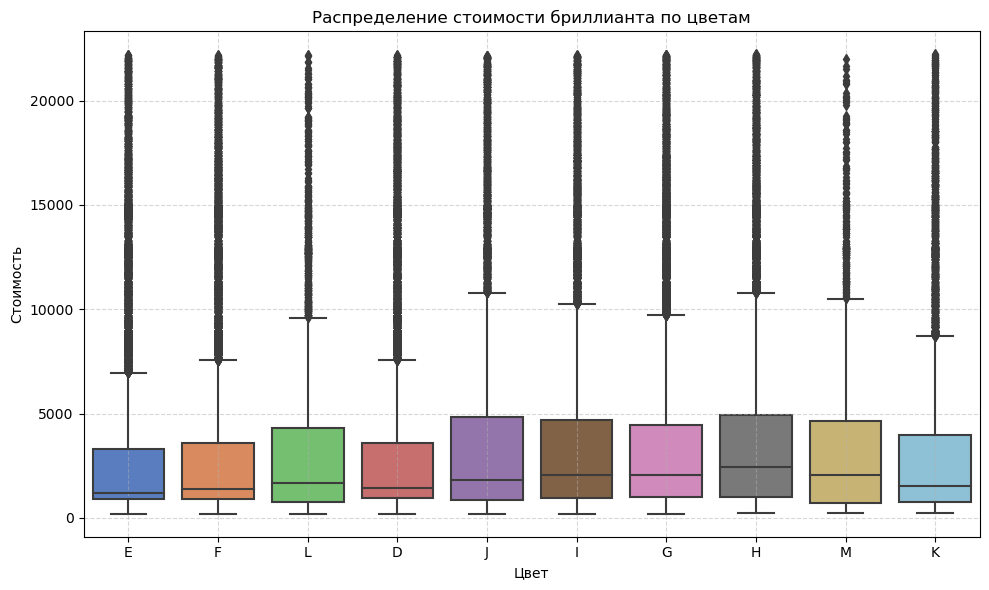

In [465]:
plot1_diamonds = diamonds.dropna(subset = 'color')

price_threshold = plot1_diamonds['total_sales_price'].quantile(0.95)
plot1_diamonds = plot1_diamonds[plot1_diamonds['total_sales_price'] <= price_threshold]

# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='total_sales_price', data=plot1_diamonds, palette='muted')
plt.title('Распределение стоимости бриллианта по цветам')
plt.xlabel('Цвет')
plt.ylabel('Стоимость')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Постройте график `лабараторная оценка - кол-во бриллиантов`:

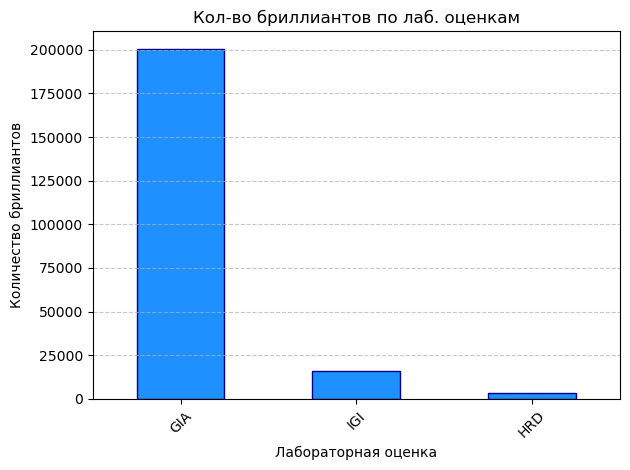

In [458]:
lab_counts = diamonds['lab'].value_counts()

lab_counts.plot(kind='bar', color='dodgerblue', edgecolor='darkblue')
plt.title('Кол-во бриллиантов по лаб. оценкам')
plt.xlabel('Лабораторная оценка')
plt.ylabel('Количество бриллиантов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Постройте график `вес бриллианта - стоимость`:

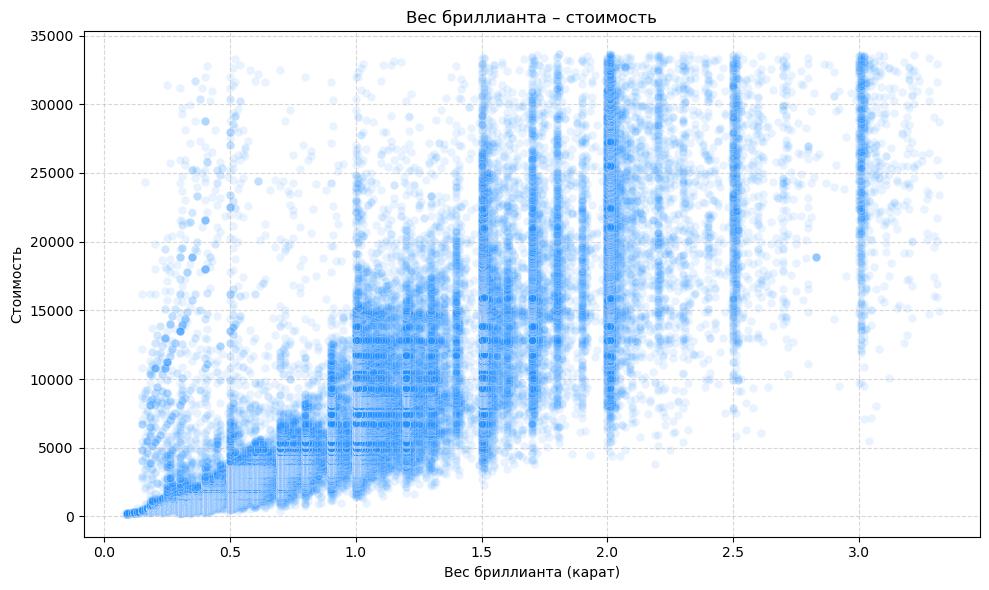

In [445]:
# Remove strong outliers using the IQR method for both carat_weight and total_sales_price
Q1_weight = diamonds['carat_weight'].quantile(0.1)
Q3_weight = diamonds['carat_weight'].quantile(0.9)
IQR_weight = Q3_weight - Q1_weight

Q1_price = diamonds['total_sales_price'].quantile(0.1)
Q3_price = diamonds['total_sales_price'].quantile(0.9)
IQR_price = Q3_price - Q1_price

plot3_diamonds = diamonds[
    (diamonds['carat_weight'] >= Q1_weight - 1.5 * IQR_weight) & (diamonds['carat_weight'] <= Q3_weight + 1.5 * IQR_weight) &
    (diamonds['total_sales_price'] >= Q1_price - 1.5 * IQR_price) & (diamonds['total_sales_price'] <= Q3_price + 1.5 * IQR_price)
]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot3_diamonds, x='carat_weight', y='total_sales_price', color='dodgerblue', alpha=0.1)

plt.title('Вес бриллианта – стоимость')
plt.xlabel('Вес бриллианта (карат)')
plt.ylabel('Стоимость')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Постройте график `система оценки GIA Cut - кол-во бриллиантов`:

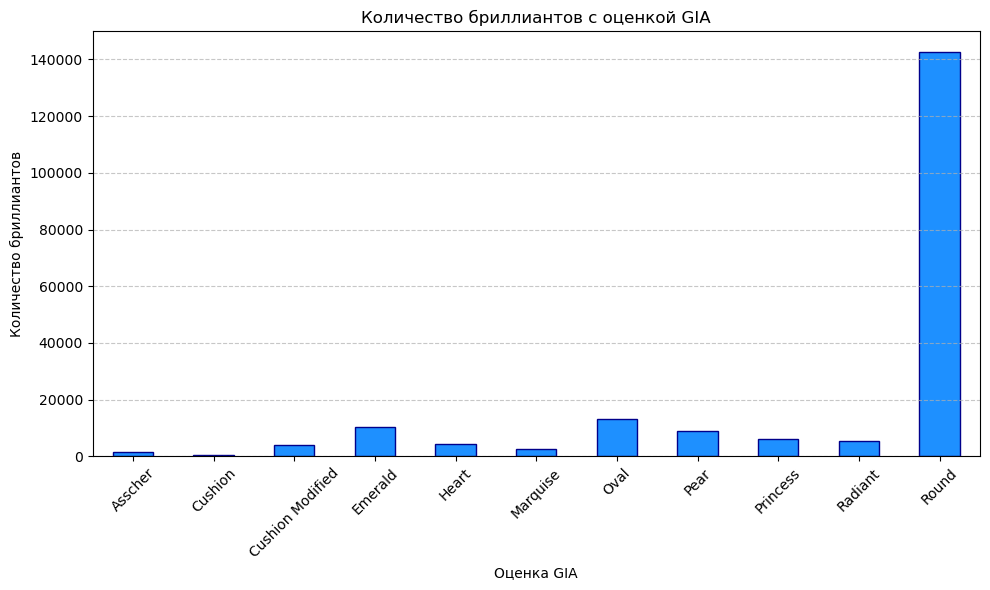

In [460]:
gia_diamond = diamonds[diamonds['lab'] == 'GIA']

cut_count = gia_diamond['cut'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
cut_count.plot(kind='bar', color='dodgerblue', edgecolor='darkblue')
plt.title('Количество бриллиантов с оценкой GIA')
plt.xlabel('Оценка GIA')
plt.ylabel('Количество бриллиантов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Сделайте выводы по построенным графикам

1 график — цвет бриллианта - стоимость
Самый дорогой цвет бриллиантов по медиане - Практически бесцветный (H).
Самый дешёвый по медиане - бесцветный (E).
Если захочется купить самый дешёвый бриллиант, то найти такой бриллиант самого жёлтого цвета (M) будет проще всего, т.к. квантиль 0.25 там ниже всех)

2 график - лабараторная оценка - кол-во бриллиантов
Скорее всего, это хранилище бриллиантов находится в США, т.к. подавляющее большинство бриллиантов оценены в США.

3 график - вес бриллианта - стоимость
Есть прямая корреляция между переменными. Стоимость распределена случайным образом, а вот у веса бриллиантов вырисовывается дискретный график, потому что часто бриллиант готовится под ровное число по весу. Резкие скачки по стоимости видны на пунктах 1, 1.5, 2.

4 график - система оценки GIA Cut - кол-во бриллиантов
В основном в базе хранятся бриллианты круглой формы (классика). Среди остальных огранок наиболее распространены Овальная, Изумруд, Груша.